# 서울시 119 구급·구조 활동 데이터 전처리

## 0. 준비

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# 실행 환경에 설치된 한글 폰트를 자동 선택
font_candidates = [
    'Malgun Gothic',      # Windows
    'AppleGothic',        # macOS
    'NanumGothic',
    'Noto Sans CJK KR',
    'Noto Sans KR',
    'Noto Sans CJK JP',
]

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)

if selected_font:
    plt.rcParams['font.family'] = selected_font
    print('그래프 한글 폰트:', selected_font)
else:
    # 폰트가 없으면 존재하지 않는 Malgun Gothic을 강제하지 않아
    # findfont 경고가 반복되는 문제를 막는다.
    print('[주의] 설치된 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')

plt.rcParams['axes.unicode_minus'] = False

DEFAULT_INPUT_DIR = Path(r'C:/ai/source/09_Project/data/outputs')
DEFAULT_OUTPUT_DIR = Path(r'C:/ai/source/09_Project/ml_data')

INPUT_DIR = Path(os.getenv('PROJECT_DATA_DIR', str(DEFAULT_INPUT_DIR)))
OUTPUT_DIR = Path(os.getenv('PROJECT_ML_DIR', str(DEFAULT_OUTPUT_DIR)))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('INPUT_DIR :', INPUT_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

def find_file(name):
    found = list(INPUT_DIR.glob(name + '.csv')) + list(INPUT_DIR.glob('*_' + name + '.csv'))
    found = list(dict.fromkeys(found))
    if not found:
        raise FileNotFoundError(f'{name}.csv 파일이 {INPUT_DIR}에 없습니다.')
    if len(found) > 1:
        print(f'  [주의] {name} 파일이 {len(found)}개 있음 -> 가장 최근 수정 파일 사용')
    return max(found, key=lambda p: p.stat().st_mtime)

def month_start(s):
    return pd.to_datetime(s, errors='coerce').dt.to_period('M').dt.to_timestamp()


그래프 한글 폰트: Malgun Gothic
INPUT_DIR : C:\ai\source\09_Project\data\outputs
OUTPUT_DIR: C:\ai\source\09_Project\ml_data


## 1. 전처리 파일 불러오기

In [2]:
required_files = [
    'accident_cause_long',
    'accident_cause_onehot',
    'ambulance_citywide_monthly',
    'ambulance_incident_monthly',
    'ambulance_monthly_gu_2022_2024',
    'ambulance_prophet',
    'ambulance_prophet_201701_202512_api',
    'ambulance_sample_gwanak_202506',
    'medical_flow_district_demand',
    'medical_flow_district_supply',
    'medical_flow_seoul_od_matrix',
    'population_rf',
]

data = {}
for name in required_files:
    path = find_file(name)
    df = pd.read_csv(path, encoding='utf-8')
    if 'district' in df.columns and 'District' not in df.columns:
        df = df.rename(columns={'district': 'District'})
    data[name] = df
    print(f'{name:40s} {str(df.shape):12s} <- {path.name}')

file_names = list(data.keys())


accident_cause_long                      (4950, 4)    <- accident_cause_long.csv
accident_cause_onehot                    (500, 16)    <- accident_cause_onehot.csv
ambulance_citywide_monthly               (48, 5)      <- ambulance_citywide_monthly.csv
ambulance_incident_monthly               (600, 9)     <- ambulance_incident_monthly.csv
ambulance_monthly_gu_2022_2024           (900, 3)     <- ambulance_monthly_gu_2022_2024.csv
ambulance_prophet                        (525, 6)     <- ambulance_prophet.csv
ambulance_prophet_201701_202512_api      (1447, 5)    <- ambulance_prophet_201701_202512_api.csv
ambulance_sample_gwanak_202506           (1, 4)       <- ambulance_sample_gwanak_202506.csv
medical_flow_district_demand             (150, 7)     <- medical_flow_district_demand.csv
medical_flow_district_supply             (150, 7)     <- medical_flow_district_supply.csv
medical_flow_seoul_od_matrix             (3750, 4)    <- medical_flow_seoul_od_matrix.csv
population_rf                 

## 2. 중복 찾기 및 제외

- 파일 포함 관계 검사: 작은 파일의 모든 행이 큰 파일 안에 있는지 `merge(indicator=True)`로 대조
- 형태만 다른 같은 데이터 검사: long ↔ wide(`pivot_table`), 구↔구 매트릭스 ↔ 구별 합계(`groupby().sum()`) 값 비교
- 같은 값 컬럼 검사: 두 컬럼씩 짝지어 `equals()`로 비교
- 값이 하나뿐인 컬럼 검사: `nunique()`가 1 이하인 컬럼 (정보 없음)
- 키 중복 행 검사: 같은 날짜·같은 구 행에 대한 `drop_duplicates()`
- 기간 겹침 정리: 여러 파일을 `concat`으로 이어 붙인 뒤 우선순위가 높은 파일의 행만 남기기

In [3]:
excluded = []   # [파일, 컬럼, 제외 이유]


# 2-1. 다른 파일 안에 통째로 들어있는 파일 찾기
def is_contained(small, big):
    # 컬럼 구성이 다르면 비교하지 않음
    if list(small.columns) != list(big.columns):
        return False
    check = small.merge(big.drop_duplicates(), how='left', indicator=True)
    return (check['_merge'] == 'both').all()


drop_files = []
for a in file_names:
    for b in file_names:
        if a == b or a in drop_files or b in drop_files:
            continue
        if len(data[a]) <= len(data[b]) and is_contained(data[a], data[b]):
            drop_files.append(a)
            excluded.append([a, '(파일 전체)', f'{b} 안에 같은 행이 모두 들어있음'])

print('다른 파일에 포함된 파일:', drop_files)

다른 파일에 포함된 파일: []


In [4]:
# 2-2. 같은 데이터를 형태만 바꿔 저장한 파일 찾기 (사고 원인 long ↔ wide)
long_df = data['accident_cause_long'].copy()
onehot_df = data['accident_cause_onehot'].copy()

cause_col = 'Cause' if 'Cause' in long_df.columns else 'cause'

wide_from_long = long_df.pivot_table(
    index=['ds', 'District'],
    columns=cause_col,
    values='rescued_count',
    fill_value=0
).reset_index()

cause_cols = [c for c in onehot_df.columns if c not in ['ds', 'District']]
check = onehot_df.merge(
    wide_from_long, on=['ds', 'District'], how='left',
    suffixes=('', '_long')
).fillna(0)

comparable = [c for c in cause_cols if c + '_long' in check.columns]
is_same = len(comparable) == len(cause_cols) and all(
    (check[c] == check[c + '_long']).all() for c in comparable
)

print('사고 원인 long 파일과 onehot 파일이 같은 내용인가?', is_same)

if is_same and 'accident_cause_long' not in drop_files:
    drop_files.append('accident_cause_long')
    excluded.append([
        'accident_cause_long', '(파일 전체)',
        'accident_cause_onehot와 같은 내용 (형태만 long)'
    ])


사고 원인 long 파일과 onehot 파일이 같은 내용인가? True


In [5]:
# 2-3. 구↔구 이동 매트릭스 ↔ 구별 합계 검증
od = data['medical_flow_seoul_od_matrix'].copy()
demand = data['medical_flow_district_demand'].copy()
supply = data['medical_flow_district_supply'].copy()

patient_col = '환자_District' if '환자_District' in od.columns else '환자_district'
hospital_col = '병원_District' if '병원_District' in od.columns else '병원_district'

od_patient = od.groupby(['ds', patient_col])['입원연인원'].sum().reset_index()
od_patient.columns = ['ds', 'District', 'od_합계']
check1 = demand.merge(od_patient, on=['ds', 'District'])
same1 = (check1['서울내입원연인원'] == check1['od_합계']).all()

od_hospital = od.groupby(['ds', hospital_col])['입원연인원'].sum().reset_index()
od_hospital.columns = ['ds', 'District', 'od_합계']
check2 = supply.merge(od_hospital, on=['ds', 'District'])
same2 = (check2['서울내환자연인원'] == check2['od_합계']).all()

print('OD 매트릭스 합계가 demand·supply와 같은가?', same1, same2)

if same1 and same2 and 'medical_flow_seoul_od_matrix' not in drop_files:
    drop_files.append('medical_flow_seoul_od_matrix')
    excluded.append([
        'medical_flow_seoul_od_matrix', '(파일 전체)',
        '구별 합계가 demand·supply와 같음 (OD 원본은 월별 통합 모델에서 제외)'
    ])


OD 매트릭스 합계가 demand·supply와 같은가? True True


In [6]:
# 2-4. 구 단위가 아니거나, 검증되지 않았거나, 이번 분석에서 직접 쓰지 않는 파일 제외
manual_drop = {
    'ambulance_citywide_monthly': '서울시 전체 합계 (구 단위 아님, 구별 파일과 정보 중복)',
    'ambulance_sample_gwanak_202506': '1개 구 1개월 표본, 검증 필요 (note 컬럼 참고)',
    'realtime_er_beds': '실시간 병상 스냅샷 (월별 예측 학습용 데이터에서는 제외)',
}

for name, reason in manual_drop.items():
    if name in data and name not in drop_files:
        drop_files.append(name)
        excluded.append([name, '(파일 전체)', reason])

clean = {}
for name in file_names:
    if name not in drop_files:
        clean[name] = data[name].copy()

print('사용할 파일:', list(clean.keys()))


사용할 파일: ['accident_cause_onehot', 'ambulance_incident_monthly', 'ambulance_monthly_gu_2022_2024', 'ambulance_prophet', 'ambulance_prophet_201701_202512_api', 'medical_flow_district_demand', 'medical_flow_district_supply', 'population_rf']


In [7]:
# 2-5. 파일 안에서 같은 값을 가진 컬럼 찾기
def find_same_columns(df):
    cols = df.columns
    same = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if df[cols[i]].equals(df[cols[j]]):
                same.append((cols[i], cols[j]))   # (남길 컬럼, 지울 컬럼)
    return same


for name, df in clean.items():
    for keep_col, drop_col in find_same_columns(df):
        if drop_col in clean[name].columns:
            clean[name] = clean[name].drop(columns=drop_col)
            excluded.append([name, drop_col, f'{keep_col}와 값이 완전히 같음'])
            print(f'[{name}] {drop_col} 제외 ({keep_col}와 같음)')

[population_rf] pop_peak 제외 (일최대인구수와 같음)


In [8]:
# 2-6. 값이 하나뿐인 컬럼 찾기 (모든 행이 같은 값이면 예측에 도움이 안 됨)
for name, df in clean.items():
    one_value_cols = df.columns[df.nunique(dropna=False) <= 1]
    for col in one_value_cols:
        clean[name] = clean[name].drop(columns=col)
        excluded.append([name, col, f'값이 하나뿐임 ({df[col].iloc[0]})'])
        print(f'[{name}] {col} 제외 (값이 하나뿐)')

In [9]:
# 2-7. 같은 키(날짜+구)가 두 번 나오는 행 제거
for name, df in clean.items():
    before = len(df)
    clean[name] = df.drop_duplicates(subset=['ds', 'District'])
    removed = before - len(clean[name])
    if removed > 0:
        excluded.append([name, '(행)', f'키 중복 행 {removed}개'])
    print(f'{name:40s} 키 중복 행 {removed}개')

accident_cause_onehot                    키 중복 행 0개
ambulance_incident_monthly               키 중복 행 0개
ambulance_monthly_gu_2022_2024           키 중복 행 0개
ambulance_prophet                        키 중복 행 0개
ambulance_prophet_201701_202512_api      키 중복 행 0개
medical_flow_district_demand             키 중복 행 0개
medical_flow_district_supply             키 중복 행 0개
population_rf                            키 중복 행 0개


In [10]:
# 2-8. 월별 출동·이송 파일 통합

monthly_source_candidates = [
    ('ambulance_incident_monthly',          1, '건별집계'),
    ('ambulance_prophet_201701_202512_api', 2, 'API_2017_2025'),
    ('ambulance_prophet_202501_202512_api', 3, 'API_2025'),
    ('ambulance_monthly_gu_2022_2024',      4, 'xlsx_2022_2024'),
]

parts = []
for name, priority, label in monthly_source_candidates:
    if name not in clean:
        continue
    part = clean[name].copy()
    part['ds'] = month_start(part['ds'])
    part['_priority'] = priority
    part['출처'] = label
    parts.append(part)

raw_monthly = pd.concat(parts, ignore_index=True, sort=False)
raw_monthly = raw_monthly.sort_values(['ds', 'District', '_priority'])

def first_valid(s):
    x = s.dropna()
    return x.iloc[0] if len(x) else np.nan

value_cols = [c for c in raw_monthly.columns
              if c not in ['ds', 'District', '_priority', '출처']]

agg_dict = {c: first_valid for c in value_cols}
agg_dict['출처'] = lambda s: '|'.join(dict.fromkeys(s.astype(str)))

monthly = (
    raw_monthly.groupby(['ds', 'District'], as_index=False)
               .agg(agg_dict)
               .sort_values(['District', 'ds'])
               .reset_index(drop=True)
)

print('월별 출동·이송 통합:', monthly.shape)
print('기간:', monthly['ds'].min(), '~', monthly['ds'].max())
display(monthly.head())

월별 출동·이송 통합: (2346, 11)
기간: 2017-01-01 00:00:00 ~ 2024-12-01 00:00:00


,ds,District,y,transport_cnt,no_transport_cnt,fire_activity_cnt,disease_cnt,non_disease_cnt,etc_cnt,transport_person,출처
0,2017-01-01,강남구,2483.0,1472.0,NaN,NaN,NaN,NaN,NaN,1511.0,API_2017_2025
1,2017-02-01,강남구,2105.0,1255.0,NaN,NaN,NaN,NaN,NaN,1270.0,API_2017_2025
2,2017-03-01,강남구,2417.0,1438.0,NaN,NaN,NaN,NaN,NaN,1459.0,API_2017_2025
3,2017-04-01,강남구,2550.0,1512.0,NaN,NaN,NaN,NaN,NaN,1531.0,API_2017_2025
4,2017-05-01,강남구,2650.0,1543.0,NaN,NaN,NaN,NaN,NaN,1558.0,API_2017_2025


## 3. 주제별 학습용 데이터프레임 만들기

In [11]:
# 여러 주제에서 같이 쓰는 생활인구 데이터 (날짜형으로 변환)
pop = clean['population_rf'].copy()
pop['ds'] = pd.to_datetime(pop['ds'])
pop = pop.sort_values(['District', 'ds']).reset_index(drop=True)
pop_cols = [c for c in pop.columns if c not in ['ds', 'District']]
print(pop['ds'].min(), '~', pop['ds'].max())


def add_past(df, past_df, cols, months, prefix):
    # past_df의 날짜를 months개월 뒤로 옮겨서 붙이면 = '몇 개월 전 값'
    past = past_df[['ds', 'District'] + cols].copy()
    past['ds'] = past['ds'] + pd.DateOffset(months=months)
    past.columns = ['ds', 'District'] + [prefix + c for c in cols]
    return df.merge(past, on=['ds', 'District'], how='left')

2018-04-05 00:00:00 ~ 2026-07-31 00:00:00


### 3-1. 이송 건수 예측 (자치구 × 월)

In [12]:
count_cols = ['y', 'transport_cnt', 'no_transport_cnt', 'fire_activity_cnt',
              'disease_cnt', 'non_disease_cnt', 'etc_cnt']

# 정답이 있는 행만 뼈대로 사용
transport = monthly[monthly['transport_cnt'].notna()][['ds', 'District', '출처', 'transport_cnt']].copy()
transport['연도'] = transport['ds'].dt.year
transport['월'] = transport['ds'].dt.month

# 전월, 전년 동월 출동·이송 건수
transport = add_past(transport, monthly, count_cols, 1, '전월_')
transport = add_past(transport, monthly, ['y', 'transport_cnt'], 12, '전년동월_')

# 전월 생활인구 (일별 -> 월평균)
pop_month = pop.copy()
pop_month['ds'] = pop_month['ds'].dt.to_period('M').dt.to_timestamp()
pop_month = pop_month.groupby(['ds', 'District'])[pop_cols].mean().reset_index()
transport = add_past(transport, pop_month, pop_cols, 1, '전월_')

# 전년도 의료이용 유출입 (연 단위)
med = clean['medical_flow_district_demand'].merge(clean['medical_flow_district_supply'], on=['ds', 'District'])
med['연도'] = pd.to_datetime(med['ds']).dt.year + 1       # 전년도 값을 올해에 붙이기
med = med.drop(columns='ds')
med.columns = [c if c in ['연도', 'District'] else '전년_' + c for c in med.columns]
transport = transport.merge(med, on=['연도', 'District'], how='left')

# 전년도 사고 원인별 구조 건수 (연 단위)
acc = clean['accident_cause_onehot'].copy()
acc['연도'] = pd.to_datetime(acc['ds']).dt.year + 1
acc = acc.drop(columns='ds')
acc.columns = [c if c in ['연도', 'District'] else '전년_' + c for c in acc.columns]
transport = transport.merge(acc, on=['연도', 'District'], how='left')

# 정답 컬럼을 맨 뒤로
transport_df = transport[[c for c in transport.columns if c != 'transport_cnt'] + ['transport_cnt']]
transport_df = transport_df.sort_values(['District', 'ds']).reset_index(drop=True)

print(transport_df.shape)
print(transport_df.groupby('출처').size())
transport_df.head()

(1746, 52)
출처
API_2017_2025                        1146
건별집계                                   12
건별집계|API_2017_2025                    288
건별집계|API_2017_2025|xlsx_2022_2024      13
건별집계|xlsx_2022_2024                   287
dtype: int64


,ds,District,출처,연도,월,전월_y,전월_transport_cnt,전월_no_transport_cnt,전월_fire_activity_cnt,전월_disease_cnt,...,전년_수난사고,전년_승강기사고,전년_안전조치,전년_위치추적,전년_인명갇힘,전년_자살추정,전년_잠금장치개방,전년_폭발사고,전년_화재,transport_cnt
0,2017-01-01,강남구,API_2017_2025,2017,1,NaN,NaN,NaN,NaN,NaN,...,40,401,0,0,350,0,0,0,70,1472.0
1,2017-02-01,강남구,API_2017_2025,2017,2,2483.0,1472.0,NaN,NaN,NaN,...,40,401,0,0,350,0,0,0,70,1255.0
2,2017-03-01,강남구,API_2017_2025,2017,3,2105.0,1255.0,NaN,NaN,NaN,...,40,401,0,0,350,0,0,0,70,1438.0
3,2017-04-01,강남구,API_2017_2025,2017,4,2417.0,1438.0,NaN,NaN,NaN,...,40,401,0,0,350,0,0,0,70,1512.0
4,2017-05-01,강남구,API_2017_2025,2017,5,2550.0,1512.0,NaN,NaN,NaN,...,40,401,0,0,350,0,0,0,70,1543.0


## 3-2. 분석용 월별 통합 데이터셋 생성

In [13]:
# 생활인구 월평균
pop_month_integrated = pop.copy()
pop_month_integrated['ds'] = pop_month_integrated['ds'].dt.to_period('M').dt.to_timestamp()
pop_numeric = list(pop_month_integrated.select_dtypes(include='number').columns)

pop_month_integrated = (
    pop_month_integrated.groupby(['ds', 'District'], as_index=False)[pop_numeric]
                        .mean()
)
pop_month_integrated = pop_month_integrated.rename(
    columns={c: 'pop_' + c for c in pop_numeric}
)

# 사고원인: 연 단위
acc_integrated = clean['accident_cause_onehot'].copy()
acc_integrated['year'] = pd.to_datetime(acc_integrated['ds'], errors='coerce').dt.year
acc_integrated = acc_integrated.drop(columns='ds')
acc_cols = [c for c in acc_integrated.columns if c not in ['year', 'District']]
acc_integrated = (
    acc_integrated.groupby(['year', 'District'], as_index=False)[acc_cols].sum()
)
acc_integrated = acc_integrated.rename(
    columns={c: 'accident_' + c for c in acc_cols}
)

# 의료이용: 연 단위
demand_integrated = clean['medical_flow_district_demand'].copy()
supply_integrated = clean['medical_flow_district_supply'].copy()

for df in [demand_integrated, supply_integrated]:
    df['year'] = pd.to_datetime(df['ds'], errors='coerce').dt.year
    df.drop(columns='ds', inplace=True)

demand_cols = [c for c in demand_integrated.columns if c not in ['year', 'District']]
supply_cols = [c for c in supply_integrated.columns if c not in ['year', 'District']]

demand_integrated = demand_integrated.rename(
    columns={c: 'med_demand_' + c for c in demand_cols}
)
supply_integrated = supply_integrated.rename(
    columns={c: 'med_supply_' + c for c in supply_cols}
)

medical_integrated = demand_integrated.merge(
    supply_integrated, on=['year', 'District'], how='outer'
)

# 최종 월별 통합
monthly_integrated = monthly.copy()
monthly_integrated['year'] = monthly_integrated['ds'].dt.year
monthly_integrated['month'] = monthly_integrated['ds'].dt.month
monthly_integrated['quarter'] = monthly_integrated['ds'].dt.quarter

season_map = {
    12: '겨울', 1: '겨울', 2: '겨울',
    3: '봄', 4: '봄', 5: '봄',
    6: '여름', 7: '여름', 8: '여름',
    9: '가을', 10: '가을', 11: '가을'
}
monthly_integrated['season'] = monthly_integrated['month'].map(season_map)

monthly_integrated = monthly_integrated.merge(
    pop_month_integrated, on=['ds', 'District'], how='left'
)
monthly_integrated = monthly_integrated.merge(
    acc_integrated, on=['year', 'District'], how='left'
)
monthly_integrated = monthly_integrated.merge(
    medical_integrated, on=['year', 'District'], how='left'
)

# 파생지표
if 'pop_total_pop' in monthly_integrated.columns:
    denom = monthly_integrated['pop_total_pop'].replace(0, np.nan)
    if 'y' in monthly_integrated.columns:
        monthly_integrated['dispatch_per_100k'] = monthly_integrated['y'] / denom * 100000
    if 'transport_cnt' in monthly_integrated.columns:
        monthly_integrated['transport_per_100k'] = monthly_integrated['transport_cnt'] / denom * 100000

if {'pop_day_pop', 'pop_night_pop'}.issubset(monthly_integrated.columns):
    monthly_integrated['day_night_pop_ratio'] = (
        monthly_integrated['pop_day_pop'] /
        monthly_integrated['pop_night_pop'].replace(0, np.nan)
    )

if {'y', 'transport_cnt'}.issubset(monthly_integrated.columns):
    monthly_integrated['transport_rate'] = (
        monthly_integrated['transport_cnt'] /
        monthly_integrated['y'].replace(0, np.nan)
    )

monthly_integrated = monthly_integrated.sort_values(['District', 'ds']).reset_index(drop=True)

print('월별 통합 데이터셋:', monthly_integrated.shape)
print('기간:', monthly_integrated['ds'].min(), '~', monthly_integrated['ds'].max())
print('자치구 수:', monthly_integrated['District'].nunique())
display(monthly_integrated.head())


월별 통합 데이터셋: (2346, 56)
기간: 2017-01-01 00:00:00 ~ 2024-12-01 00:00:00
자치구 수: 25


,ds,District,y,transport_cnt,no_transport_cnt,fire_activity_cnt,disease_cnt,non_disease_cnt,etc_cnt,transport_person,...,med_demand_응급실입원연인원,med_supply_총처리연인원,med_supply_서울내환자연인원,med_supply_서울외유입연인원,med_supply_유입률,med_supply_응급실처리연인원,dispatch_per_100k,transport_per_100k,day_night_pop_ratio,transport_rate
0,2017-01-01,강남구,2483.0,1472.0,NaN,NaN,NaN,NaN,NaN,1511.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.592831
1,2017-02-01,강남구,2105.0,1255.0,NaN,NaN,NaN,NaN,NaN,1270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596200
2,2017-03-01,강남구,2417.0,1438.0,NaN,NaN,NaN,NaN,NaN,1459.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.594952
3,2017-04-01,강남구,2550.0,1512.0,NaN,NaN,NaN,NaN,NaN,1531.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.592941
4,2017-05-01,강남구,2650.0,1543.0,NaN,NaN,NaN,NaN,NaN,1558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.582264


## 3-3. 결측치가 과도한 컬럼·행 제외

월별 통합 과정에서 기간이 짧거나 특정 연도에만 존재하는 변수는 결측치가 많이 발생할 수 있습니다.

### 제외 기준

- **컬럼 결측률 50% 이상 → 자동 제외**
- 보호 컬럼은 `ds`, `District`, `y`, `transport_cnt`만 사용
- 따라서 `no_transport_cnt`, `fire_activity_cnt`, `disease_cnt`, `non_disease_cnt`, `etc_cnt` 등을 포함한 일반 변수는 **이름과 관계없이 실제 결측률이 50% 이상이면 제거**
- 컬럼 제거 후, 남은 분석 변수의 **행별 결측률이 50% 이상인 행도 제외**
- 어떤 컬럼과 행이 제거되었는지 CSV 보고서로 저장

In [14]:
# 결측치 제외 기준
COLUMN_MISSING_THRESHOLD = 0.50
ROW_MISSING_THRESHOLD = 0.50

# 식별자와 핵심 목표변수만 보호
# 나머지 변수는 결측률 50% 이상이면 자동 제외
protected_cols = [
    'ds',
    'District',
    'y',
    'transport_cnt',
]
protected_cols = [c for c in protected_cols if c in monthly_integrated.columns]

# 1. 컬럼 단위 결측치 제거

missing_before = (
    monthly_integrated.isna().mean()
    .sort_values(ascending=False)
    .rename('missing_rate')
    .to_frame()
)
missing_before['missing_count'] = monthly_integrated.isna().sum()

missing_before['protected'] = missing_before.index.isin(protected_cols)
missing_before['excluded'] = (
    (missing_before['missing_rate'] >= COLUMN_MISSING_THRESHOLD)
    & (~missing_before['protected'])
)

drop_missing_cols = missing_before.index[
    missing_before['excluded']
].tolist()

print(f'[컬럼 제거 기준] 결측률 >= {COLUMN_MISSING_THRESHOLD:.0%}')
print('보호 컬럼:', protected_cols)
print('제외 컬럼 수:', len(drop_missing_cols))

if drop_missing_cols:
    display(
        missing_before.loc[
            drop_missing_cols,
            ['missing_count', 'missing_rate', 'protected', 'excluded']
        ]
    )

monthly_integrated = monthly_integrated.drop(
    columns=drop_missing_cols,
    errors='ignore'
)

# 2. 행 단위 결측치 제거

# 식별자/목표변수를 제외한 실제 분석 특성만 기준으로 판단
row_check_cols = [
    c for c in monthly_integrated.columns
    if c not in protected_cols
]

if row_check_cols:
    row_missing_rate = (
        monthly_integrated[row_check_cols]
        .isna()
        .mean(axis=1)
    )
    drop_row_mask = row_missing_rate >= ROW_MISSING_THRESHOLD
else:
    row_missing_rate = pd.Series(
        0.0,
        index=monthly_integrated.index
    )
    drop_row_mask = pd.Series(
        False,
        index=monthly_integrated.index
    )

removed_rows = monthly_integrated.loc[
    drop_row_mask,
    ['ds', 'District']
].copy()
removed_rows['missing_rate'] = row_missing_rate.loc[
    drop_row_mask
].values

print(f'\n[행 제거 기준] 남은 분석 변수 중 결측률 >= {ROW_MISSING_THRESHOLD:.0%}')
print('제외 행 수:', int(drop_row_mask.sum()))

monthly_integrated = (
    monthly_integrated.loc[~drop_row_mask]
    .sort_values(['District', 'ds'])
    .reset_index(drop=True)
)


# 3. 결과 보고서 저장

missing_report_path = OUTPUT_DIR / '01_missing_value_report.csv'
removed_rows_path = OUTPUT_DIR / '02_removed_rows_missing.csv'

missing_before.reset_index(names='column').to_csv(
    missing_report_path,
    index=False,
    encoding='utf-8-sig'
)

removed_rows.to_csv(
    removed_rows_path,
    index=False,
    encoding='utf-8-sig'
)

print('\n결측치 처리 후 크기:', monthly_integrated.shape)
print('제거된 컬럼:', drop_missing_cols)
print('결측치 보고서:', missing_report_path)
print('제외 행 보고서:', removed_rows_path)

[컬럼 제거 기준] 결측률 >= 50%
보호 컬럼: ['ds', 'District', 'y', 'transport_cnt']
제외 컬럼 수: 5


,missing_count,missing_rate,protected,excluded
no_transport_cnt,1746,0.744246,False,True
fire_activity_cnt,1746,0.744246,False,True
disease_cnt,1746,0.744246,False,True
non_disease_cnt,1746,0.744246,False,True
etc_cnt,1746,0.744246,False,True



[행 제거 기준] 남은 분석 변수 중 결측률 >= 50%
제외 행 수: 354

결측치 처리 후 크기: (1992, 51)
제거된 컬럼: ['no_transport_cnt', 'fire_activity_cnt', 'disease_cnt', 'non_disease_cnt', 'etc_cnt']
결측치 보고서: C:\ai\source\09_Project\ml_data\01_missing_value_report.csv
제외 행 보고서: C:\ai\source\09_Project\ml_data\02_removed_rows_missing.csv


In [15]:
# 품질 확인 및 저장
print('ds + District 중복:', monthly_integrated.duplicated(['ds', 'District']).sum())

check_cols = [c for c in [
    'y', 'transport_cnt', 'transport_person',
    'pop_total_pop', 'pop_day_pop', 'pop_night_pop',
    'dispatch_per_100k', 'transport_per_100k'
] if c in monthly_integrated.columns]

quality = pd.DataFrame({
    'dtype': monthly_integrated[check_cols].dtypes.astype(str),
    'missing_count': monthly_integrated[check_cols].isna().sum(),
    'missing_rate': monthly_integrated[check_cols].isna().mean().round(4)
})
display(quality)

monthly_path = OUTPUT_DIR / 'monthly_integrated_dataset.csv'
monthly_integrated.to_csv(monthly_path, index=False, encoding='utf-8-sig')
print('저장 완료:', monthly_path)


print('\n[결측치 처리 후 전체 컬럼 결측률 상위 20개]')
display(
    monthly_integrated.isna().mean()
    .sort_values(ascending=False)
    .head(20)
    .rename('missing_rate')
    .to_frame()
)

ds + District 중복: 0


,dtype,missing_count,missing_rate
y,float64,0,0.0000
transport_cnt,float64,600,0.3012
transport_person,float64,899,0.4513
pop_total_pop,float64,0,0.0000
pop_day_pop,float64,0,0.0000
pop_night_pop,float64,0,0.0000
dispatch_per_100k,float64,0,0.0000
transport_per_100k,float64,600,0.3012


저장 완료: C:\ai\source\09_Project\ml_data\monthly_integrated_dataset.csv

[결측치 처리 후 전체 컬럼 결측률 상위 20개]


,missing_rate
transport_person,0.451305
med_supply_응급실처리연인원,0.397590
med_demand_응급실입원연인원,0.397590
transport_rate,0.301205
transport_cnt,0.301205
transport_per_100k,0.301205
med_supply_총처리연인원,0.108434
med_demand_총입원연인원,0.108434
med_demand_서울내입원연인원,0.108434
med_demand_서울외유출연인원,0.108434


### 3-2. 인구 밀집 예측 (자치구 × 일)

In [16]:
TARGET_POP = '일최대인구수'

pop_df = pop.copy()
pop_df['월'] = pop_df['ds'].dt.month
pop_df['요일'] = pop_df['ds'].dt.dayofweek          # 0=월요일 ... 6=일요일
pop_df['주말여부'] = (pop_df['요일'] >= 5).astype(int)

# 전일 값 (구별로 하루씩 밀기)
lag1 = pop_df.groupby('District')[pop_cols].shift(1)
lag1.columns = ['전일_' + c for c in pop_cols]

# 7일 전 같은 요일 값
pop_df['7일전_' + TARGET_POP] = pop_df.groupby('District')[TARGET_POP].shift(7)

population_df = pd.concat(
    [pop_df[['ds', 'District', '월', '요일', '주말여부', '7일전_' + TARGET_POP]], lag1, pop_df[[TARGET_POP]]],
    axis=1)
population_df = population_df.dropna().reset_index(drop=True)

print(population_df.shape)
population_df.head()

(75825, 20)


,ds,District,월,요일,주말여부,7일전_일최대인구수,전일_total_pop,전일_내국인생활인구수,전일_장기체류외국인인구수,전일_단기체류외국인인구수,전일_일최대인구수,전일_일최소인구수,전일_day_pop,전일_night_pop,전일_일최대이동인구수,전일_서울외유입인구수,전일_동일자치구행정동간이동인구수,전일_자치구간이동인구수,전일_pop_diff,일최대인구수
0,2018-04-12,강남구,4,3,0,1.147911e+06,908821.8711,865912.1889,22565.2141,20344.4682,1.136464e+06,694338.4369,1.098492e+06,773343.3511,748381.9632,223057.8765,138173.1101,387150.9766,325148.4480,1.141658e+06
1,2018-04-13,강남구,4,4,0,1.151434e+06,914989.5755,871179.9344,23023.7004,20785.9408,1.141658e+06,697891.0646,1.103631e+06,780245.6758,755681.2506,229187.5221,138339.7021,388154.0264,323385.3593,1.138334e+06
2,2018-04-14,강남구,4,5,1,9.206919e+05,910904.8321,867629.4134,23028.0340,20247.3847,1.138334e+06,699855.8534,1.096527e+06,778317.8563,744407.8148,224224.4065,137947.1677,382236.2406,318208.7419,9.172530e+05
3,2018-04-15,강남구,4,6,1,8.256871e+05,783846.8350,746014.3505,19218.2014,18614.2831,9.172530e+05,692708.7447,8.711495e+05,721487.7636,497627.1898,155806.3051,125476.8579,216344.0268,149661.7714,7.984891e+05
4,2018-04-16,강남구,4,0,0,1.127112e+06,723599.9561,689129.1607,16815.4499,17655.3455,7.984891e+05,669247.1509,7.731354e+05,688217.5094,403246.4693,112324.0399,125258.2477,165664.1817,84917.8721,1.118871e+06


In [17]:
# 주제별 데이터 저장
transport_df.to_csv(OUTPUT_DIR / 'transport_dataset.csv', index=False, encoding='utf-8-sig')
population_df.to_csv(OUTPUT_DIR / 'population_dataset.csv', index=False, encoding='utf-8-sig')
print('저장 완료:', os.listdir(OUTPUT_DIR))

저장 완료: ['01_missing_value_report.csv', '02_removed_rows_missing.csv', 'monthly_gu_integrated.csv', 'monthly_integrated_dataset.csv', 'population_dataset.csv', 'transport_dataset.csv']


## 4. 컬럼 연관성 분석 및 예측 컬럼 선택

### 학습 데이터 결측치 처리 기준

- 월별 통합 데이터셋: 기존대로 **결측률 50% 이상 컬럼 제외**
- 예측 모델용 feature 선택: **결측률 20% 초과 변수 제외**
- 변수를 하나씩 추가할 때 완전행 보존율이 **70% 미만으로 떨어지면 해당 변수 제외**
- 따라서 `transport_selected.csv`에서 여러 결측 변수가 겹쳐 행이 과도하게 삭제되는 현상을 줄입니다.
- 결측값을 임의 평균/0으로 채우지 않아 시계열 정보 왜곡도 피합니다.


In [18]:
def select_features(
    df, target, candidates,
    min_corr=0.3,
    max_inter_corr=0.9,
    max_missing=0.20,
    min_row_retention=0.70
):
    rows = []

    # 1) 모델 학습용 변수는 결측률이 높은 변수를 더 엄격하게 제외
    # 통합 데이터셋 기준(50%)과 별개로, 학습 데이터의 행 손실을 줄이기 위해 20% 사용
    usable = []
    for col in candidates:
        missing = df[col].isna().mean()
        if missing > max_missing:
            rows.append([col, np.nan, '제외', f'결측 {missing:.0%} > {max_missing:.0%}'])
        else:
            usable.append(col)

    if not usable:
        result = pd.DataFrame(rows, columns=['컬럼', '정답과_상관계수', '결과', '이유'])
        return [], result

    # 2) 정답과의 상관계수
    corr_target = df[usable + [target]].corr()[target].drop(target)
    corr_order = corr_target.abs().sort_values(ascending=False)

    # 3) 상관이 큰 순서대로 선택
    #    이미 선택한 변수와 지나치게 유사하거나,
    #    추가했을 때 완전행 보존율이 너무 낮아지는 변수는 제외
    selected = []

    for col in corr_order.index:
        r = corr_target[col]

        if pd.isna(r):
            rows.append([col, r, '제외', '상관계수 계산 불가 (값 변화 없음)'])
            continue

        if abs(r) < min_corr:
            rows.append([col, r, '제외', f'정답과 상관 약함 (|r| < {min_corr})'])
            continue

        similar = [s for s in selected if abs(df[col].corr(df[s])) >= max_inter_corr]
        if similar:
            rows.append([col, r, '제외', f'{similar[0]}와 너무 비슷함'])
            continue

        trial_cols = selected + [col, target]
        retention = df[trial_cols].notna().all(axis=1).mean()

        if retention < min_row_retention:
            rows.append([
                col, r, '제외',
                f'추가 시 완전행 보존율 {retention:.0%} < {min_row_retention:.0%}'
            ])
            continue

        selected.append(col)
        rows.append([col, r, '선택', f'완전행 보존율 {retention:.0%}'])

    result = pd.DataFrame(
        rows,
        columns=['컬럼', '정답과_상관계수', '결과', '이유']
    )
    return selected, result


def draw_heatmap(df, cols, title, save_path):
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(1 + len(cols) * 0.8, len(cols) * 0.7))
    sns.heatmap(corr, vmin=-1, vmax=1, annot=True, fmt='.2f', cmap='Blues', mask=mask)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


===== transport (정답: transport_cnt, 전체 1746행) =====
                  컬럼  정답과_상관계수 결과                       이유
 전월_no_transport_cnt       NaN 제외             결측 67% > 20%
전월_fire_activity_cnt       NaN 제외             결측 67% > 20%
      전월_disease_cnt       NaN 제외             결측 67% > 20%
  전월_non_disease_cnt       NaN 제외             결측 67% > 20%
          전월_etc_cnt       NaN 제외             결측 67% > 20%
        전월_total_pop       NaN 제외             결측 22% > 20%
         전월_내국인생활인구수       NaN 제외             결측 22% > 20%
       전월_장기체류외국인인구수       NaN 제외             결측 22% > 20%
       전월_단기체류외국인인구수       NaN 제외             결측 22% > 20%
           전월_일최대인구수       NaN 제외             결측 22% > 20%
           전월_일최소인구수       NaN 제외             결측 22% > 20%
          전월_day_pop       NaN 제외             결측 22% > 20%
        전월_night_pop       NaN 제외             결측 22% > 20%
         전월_일최대이동인구수       NaN 제외             결측 22% > 20%
         전월_서울외유입인구수       NaN 제외             결측 22% > 20%
   전

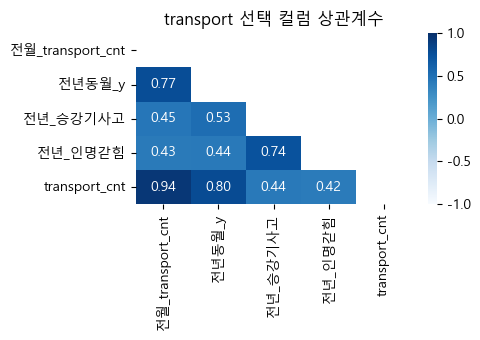

===== population (정답: 일최대인구수, 전체 75825행) =====
               컬럼  정답과_상관계수 결과                    이유
       7일전_일최대인구수  0.978669 선택          완전행 보존율 100%
        전일_일최대인구수  0.960668 제외    7일전_일최대인구수와 너무 비슷함
       전일_day_pop  0.951252 제외    7일전_일최대인구수와 너무 비슷함
     전일_total_pop  0.944468 제외    7일전_일최대인구수와 너무 비슷함
      전일_내국인생활인구수  0.931651 제외    7일전_일최대인구수와 너무 비슷함
     전일_night_pop  0.874927 선택          완전행 보존율 100%
        전일_일최소인구수  0.860116 제외  전일_night_pop와 너무 비슷함
      전일_일최대이동인구수  0.844614 선택          완전행 보존율 100%
      전일_서울외유입인구수  0.787113 제외   전일_일최대이동인구수와 너무 비슷함
     전일_자치구간이동인구수  0.648201 제외   전일_일최대이동인구수와 너무 비슷함
전일_동일자치구행정동간이동인구수  0.612631 선택          완전행 보존율 100%
      전일_pop_diff  0.493986 선택          완전행 보존율 100%
    전일_단기체류외국인인구수  0.273678 제외 정답과 상관 약함 (|r| < 0.3)
    전일_장기체류외국인인구수  0.180816 제외 정답과 상관 약함 (|r| < 0.3)
             주말여부 -0.095424 제외 정답과 상관 약함 (|r| < 0.3)
               요일 -0.076144 제외 정답과 상관 약함 (|r| < 0.3)
                월  0.005783 제외 정답과 상관 약함 (|r| < 0.3)

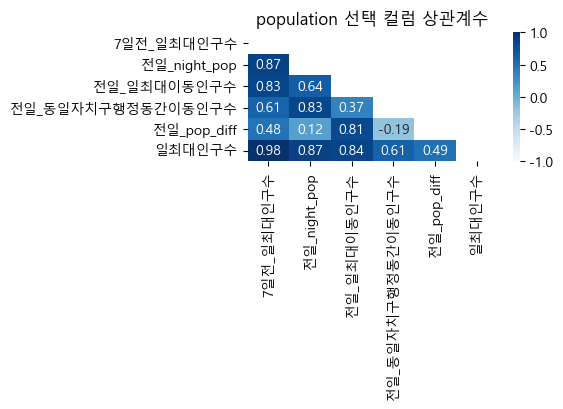

In [19]:
# 주제별 설정: (데이터, 정답 컬럼, 키 컬럼 = 특성이 아닌 컬럼)
topics = {
    'transport':  (transport_df,  'transport_cnt', ['ds', 'District', '출처']),
    'population': (population_df, TARGET_POP,      ['ds', 'District']),
}

selected_features = {}

for topic, (df, target, keys) in topics.items():
    candidates = [
        c for c in df.select_dtypes('number').columns
        if c != target and c not in keys
    ]

    selected, result = select_features(
        df,
        target,
        candidates,
        max_missing=0.20,       # 학습용 변수는 결측률 20% 초과 시 제외
        min_row_retention=0.70  # 선택 변수 조합으로 최소 70% 행 유지
    )
    selected_features[topic] = selected

    print(f'===== {topic} (정답: {target}, 전체 {len(df)}행) =====')
    print(result.to_string(index=False))

    result.to_csv(
        OUTPUT_DIR / f'features_{topic}.csv',
        index=False,
        encoding='utf-8-sig'
    )

    # 키 + 선택 변수 + 정답에서만 완전행 생성
    required_cols = keys + selected + [target]
    selected_df = (
        df[required_cols]
        .dropna(subset=selected + [target])
        .reset_index(drop=True)
    )

    selected_df.to_csv(
        OUTPUT_DIR / f'{topic}_selected.csv',
        index=False,
        encoding='utf-8-sig'
    )

    retention = len(selected_df) / len(df) if len(df) else 0

    print(f'선택 변수: {selected}')
    print(
        f'-> {topic}_selected.csv : '
        f'{len(df)}행 중 {len(selected_df)}행 저장 '
        f'(보존율 {retention:.1%})'
    )
    print()

    if selected:
        draw_heatmap(
            df,
            selected + [target],
            f'{topic} 선택 컬럼 상관계수',
            OUTPUT_DIR / f'fig_corr_{topic}.png'
        )


In [20]:
# 최종 결과 요약
for topic, cols in selected_features.items():
    print(f'{topic:12s} 선택 {len(cols)}개: {cols}')

transport    선택 4개: ['전월_transport_cnt', '전년동월_y', '전년_승강기사고', '전년_인명갇힘']
population   선택 5개: ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff']
